# Fixed-horizon seizure forecasting from scalp EEG

This notebook assesses and implements a **five-minute, discrete-time seizure forecast** from pre-recorded EDF scalp EEG. It reads two minutes of strictly past EEG context, evaluates only at five-second boundaries, and keeps the original episode end fixed. After a boundary is crossed, the elapsed rectangle disappears; a new far-right rectangle is **not** appended.

The output is a proper distribution over 60 possible onset intervals **plus an explicit no-seizure outcome**. A second timing-only view normalizes the 60 bars conditional on a seizure occurring before the fixed end.

> **Research-only warning:** this small retrospective dataset and model are not validated for diagnosis, treatment, patient warning, or any clinical decision.

In [1]:
from pathlib import Path
import json
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / 'rolling_seizure_forecasting.py').exists():
    candidates = list(NOTEBOOK_DIR.rglob('rolling_seizure_forecasting.py'))
    if len(candidates) != 1:
        raise FileNotFoundError('Run this notebook from its scripts directory or repository root.')
    NOTEBOOK_DIR = candidates[0].parent
sys.path.insert(0, str(NOTEBOOK_DIR))

import rolling_seizure_forecasting as rsf

paths = rsf.project_paths(NOTEBOOK_DIR)
config = rsf.ForecastConfig()
config.validate()
paths['processed'].mkdir(parents=True, exist_ok=True)
paths['results'].mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Module version: {rsf.MODULE_VERSION}')
print(f'Raw data: {paths["raw"]}')
print(f'Results:  {paths["results"]}')

Module version: 1.0.0
Raw data: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\data\raw
Results:  C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast


## 1. Mathematical assessment

Let $\Delta=5$ seconds and $K=300/5=60$. At landmark $t$, define the discrete conditional hazard

$$h_j(x_t)=P\{T\in(t+(j-1)\Delta,t+j\Delta]\mid T>t+(j-1)\Delta,x_t\}.$$

The onset probability mass in bin $j$ and the no-event mass are

$$p_j=h_j\prod_{r<j}(1-h_r),\qquad p_{\varnothing}=\prod_{r=1}^{K}(1-h_r).$$

Therefore $\sum_{j=1}^{K}p_j+p_{\varnothing}=1$. This is mathematically consistent and guarantees a non-increasing survival curve.

The original proposal—forcing only the 60 seizure-time bins to sum to one—is consistent **only conditional on a seizure being certain in five minutes**. For ordinary interictal EEG that assumption is false. The useful display is instead

$$P(T\text{ in bin }j\mid T\le t+300,x_t)=\frac{p_j}{1-p_{\varnothing}},$$

shown beside the absolute five-minute event risk $1-p_{\varnothing}$. If rectangle heights represent a density, the Riemann sum is $\sum_j f_j\Delta=1$; if rectangles are labeled with probability mass $p_j$, then $\sum_jp_j=1$. Those conventions should not be mixed.

The episode begins only after 120 seconds of past context. At times $t_m=t_0+m\Delta$, the implementation recomputes once per crossed boundary using only EEG ending at $t_m$. It retains bins through the original end $t_0+300$ and folds all later probability into the no-event-by-fixed-end mass. It never pushes the right edge forward.

If no new EEG were used, deleting an elapsed bin would instead be a pure conditional update: divide all remaining masses, including $p_{\varnothing}$, by one minus the elapsed mass. This notebook implements the stronger **fresh landmark forecast** at fixed steps, not that passive update.

## 2. Loss function

The implemented loss is the discrete survival negative log-likelihood, expressed as binary cross-entropy over only the bins for which a landmark is at risk. If onset occurs in bin $k$,

$$\mathcal L=-\log h_k-\sum_{j<k}\log(1-h_j).$$

If no onset is observed during the five-minute follow-up,

$$\mathcal L=-\sum_{j=1}^{K}\log(1-h_j).$$

This naturally handles the no-event outcome and produces a normalized distribution. A direct alternative is 61-class cross-entropy over 60 onset bins plus no-event. The hazard parameterization is preferable here because it encodes survival monotonicity and can later accommodate right-censoring. Class weighting or focal loss should not be added casually: both can damage probability calibration. If used for optimization, probabilities should be recalibrated on a separate validation set.

## 3. Recommended evaluation

| Quantity | Definition and use |
|---|---|
| Seizure sensitivity | Fraction of seizure episodes receiving at least one pre-onset warning. Report patient-level uncertainty. |
| Time in warning (TiW) | Fraction of eligible monitored time for which the warning is active. Sensitivity must be interpreted against TiW. |
| False alarms/hour | Rising warning edges during interictal follow-up divided by interictal hours. State warning persistence/refractory rules. |
| Multicategory Brier score | Proper score across the 60 onset bins plus no-event. Lower is better. |
| Integrated survival Brier score | Mean squared survival-probability error across all 60 endpoints. |
| Brier skill score | Improvement over a prespecified baseline forecast; values above zero are better than baseline. |
| Calibration/reliability | Compare forecasted and observed event frequencies; AUROC alone cannot establish calibration. |
| Negative log-likelihood | Strictly proper score that strongly penalizes confident errors. |
| Sensitivity–TiW curve / AUROC | Threshold-free operational discrimination. Use seizure-time surrogates for a chance benchmark. |
| Conditional timing MAE | Error in expected onset time given that an event occurs; always report it separately from event risk. |

Metrics and warning thresholds must be computed on continuous, chronologically held-out data. This notebook uses a patient-disjoint holdout and chooses its warning threshold on development patients only, but the available recordings are still too short for a clinically stable false-alarm estimate.

## 4. Closely related approaches

- [DeepHit (Lee et al., 2018)](https://doi.org/10.1609/aaai.v32i1.11842) directly learns a probability mass function over discrete event times; it is the closest general time-to-event analogue to 60 future rectangles.
- [Dynamic-DeepHit (Lee, Yoon & van der Schaar, 2020)](https://doi.org/10.1109/TBME.2019.2909027) updates discrete time-to-event distributions from longitudinal measurements, closely matching scheduled landmark updates.
- [Nnet-survival (Gensheimer & Narasimhan, 2019)](https://doi.org/10.7717/peerj.6257) estimates interval-specific conditional hazards with a neural likelihood; this is the loss used here with a smaller tree model suitable for 47 seizures.
- [McKinsey et al. (2022)](https://doi.org/10.1080/24725579.2022.2051645) used random survival forests to estimate seizure-onset hazard across a prediction horizon, including a five-minute horizon, although their evaluation was in animal EEG rather than human scalp EEG.
- [EEGSurvNet (Lemoine et al., 2026)](https://doi.org/10.1002/epi.70101) predicts time to a future seizure from routine human EEG using six discrete hazard intervals. Its horizon is long-term recurrence, not minutes-before-onset forecasting, but its output construction is directly relevant.
- [Winterhalder et al. (2003)](https://doi.org/10.1016/S1525-5050(03)00105-7) formalized seizure-prediction assessment using sensitivity and false prediction rate.
- [Proix et al. (2021)](https://doi.org/10.1016/S1474-4422(20)30396-3) evaluated probabilistic seizure forecasts on unseen data with sensitivity versus time in warning and Brier skill score.
- [Kuhlmann et al. (2018)](https://pubmed.ncbi.nlm.nih.gov/30131521/) review methodological requirements and clinical translation pitfalls for seizure prediction.

The exact combination here—human scalp EEG, five-second bins, a fixed shrinking five-minute episode, and removal of elapsed bars—is an adaptation of discrete-time dynamic survival forecasting rather than a standard established seizure-prediction protocol.

## 5. Read and audit the EDF study

The project already contains an audited `event_inventory.csv` derived from the Siena scalp EEG annotations. The model reads voltage samples directly from the raw EDF files. Positive episodes begin 300 seconds before each annotated onset. A matched interictal episode is selected for the same patient, with two minutes of context, five minutes of displayed follow-up, another five minutes needed to label the last landmark, and a five-minute buffer around every annotated seizure.

In [2]:
events = rsf.load_event_inventory(paths['event_inventory'])
edf_files = sorted(paths['raw'].rglob('*.edf'))
manifest = rsf.build_episode_manifest(events, paths['raw'], config)

study_summary = pd.DataFrame({
    'quantity': [
        'patients', 'EDF recordings', 'annotated seizures', 'eligible seizures',
        'preictal episodes', 'matched interictal episodes', 'bin width (s)',
        'horizon (s)', 'past EEG context (s)', 'total EDF size (GB)'
    ],
    'value': [
        events['patient_id'].nunique(), len(edf_files), len(events),
        int(events['eligible_preictal'].sum()),
        int(manifest['episode_type'].eq('preictal').sum()),
        int(manifest['episode_type'].eq('interictal').sum()),
        config.bin_seconds, config.horizon_seconds, config.context_seconds,
        round(sum(path.stat().st_size for path in edf_files) / 1e9, 2),
    ]
})
display(study_summary)
display(manifest.groupby(['patient_id', 'episode_type']).size().unstack(fill_value=0))
display(manifest.head(8))

,quantity,value
0,patients,14.0
1,EDF recordings,41.0
2,annotated seizures,47.0
3,eligible seizures,47.0
4,preictal episodes,47.0
5,matched interictal episodes,47.0
6,bin width (s),5.0
7,horizon (s),300.0
8,past EEG context (s),120.0
9,total EDF size (GB),21.8


episode_type,interictal,preictal
patient_id,,
PN00,5,5
PN01,2,2
PN03,2,2
PN05,3,3
PN06,5,5
PN07,1,1
PN09,3,3
PN10,10,10
PN11,1,1


,episode_id,patient_id,source_event_id,episode_type,recording,edf_path,anchor_seconds,fixed_end_seconds,event_onset_seconds
0,PN00_interictal_01,PN00,,interictal,PN00-1.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,120.0,420.0,NaN
1,PN00_interictal_02,PN00,,interictal,PN00-1.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1860.0,2160.0,NaN
2,PN00_interictal_03,PN00,,interictal,PN00-3.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1260.0,1560.0,NaN
3,PN00_interictal_04,PN00,,interictal,PN00-3.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1680.0,1980.0,NaN
4,PN00_interictal_05,PN00,,interictal,PN00-5.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,1500.0,1800.0,NaN
5,PN00_S01_preictal,PN00,PN00_S01,preictal,PN00-1.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,843.0,1143.0,1143.0
6,PN00_S02_preictal,PN00,PN00_S02,preictal,PN00-2.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,920.0,1220.0,1220.0
7,PN00_S03_preictal,PN00,PN00_S03,preictal,PN00-3.edf,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-...,465.0,765.0,765.0


## 6. Causal EEG features at each landmark

Each five-second micro-window is detrended and robustly common-median referenced. Implausibly flat or extreme channels are rejected. The signal is resampled to 128 Hz, and robust scalp summaries are calculated for relative and log absolute power in delta, theta, alpha, beta, and 30–45 Hz low gamma, plus RMS, line length, spectral entropy, and usable-channel fraction. The preceding 24 micro-windows are summarized by mean, standard deviation, latest value, and slope, giving 56 features.

Only samples strictly before the landmark are used. The cache below contains derived features, never altered raw EDF data.

In [3]:
cache_csv = paths['processed'] / 'landmark_features.csv'
cache_metadata = paths['processed'] / 'landmark_features_metadata.json'
started = time.time()
landmarks = rsf.build_landmark_dataset(
    manifest,
    cache_csv=cache_csv,
    cache_metadata_json=cache_metadata,
    config=config,
    force=False,
    verbose=True,
)
print(f'Feature table: {landmarks.shape[0]:,} landmarks x {len(rsf.MODEL_FEATURE_COLUMNS)} model features')
print(f'Elapsed: {time.time() - started:.1f} seconds')

feature_audit = pd.DataFrame({
    'check': ['expected row count', 'finite model features', '60 landmarks per episode', 'both target types present'],
    'passed': [
        len(landmarks) == len(manifest) * rsf.N_BINS,
        np.isfinite(landmarks[rsf.MODEL_FEATURE_COLUMNS].to_numpy()).all(),
        landmarks.groupby('episode_id').size().eq(rsf.N_BINS).all(),
        landmarks['has_event_in_5m'].nunique() == 2,
    ]
})
assert feature_audit['passed'].all(), feature_audit
display(feature_audit)
display(landmarks[['episode_id', 'patient_id', 'episode_type', 'landmark_step', 'time_to_event_seconds', 'event_bin'] + rsf.MODEL_FEATURE_COLUMNS[:6]].head(10))

Loaded 5,640 cached landmark rows.
Feature table: 5,640 landmarks x 56 model features
Elapsed: 0.1 seconds


,check,passed
0,expected row count,True
1,finite model features,True
2,60 landmarks per episode,True
3,both target types present,True


,episode_id,patient_id,episode_type,landmark_step,time_to_event_seconds,event_bin,relative_delta_mean,relative_delta_std,relative_delta_last,relative_delta_slope,relative_theta_mean,relative_theta_std
0,PN00_interictal_01,PN00,interictal,0,NaN,-1,0.698608,0.070337,0.778002,0.000826,0.081961,0.026852
1,PN00_interictal_01,PN00,interictal,1,NaN,-1,0.693351,0.075046,0.567785,0.000554,0.082803,0.027365
2,PN00_interictal_01,PN00,interictal,2,NaN,-1,0.682735,0.081418,0.513694,0.000358,0.085090,0.027010
3,PN00_interictal_01,PN00,interictal,3,NaN,-1,0.687222,0.078362,0.684402,0.000131,0.085644,0.027404
4,PN00_interictal_01,PN00,interictal,4,NaN,-1,0.694937,0.082742,0.829389,0.000322,0.082537,0.028618
5,PN00_interictal_01,PN00,interictal,5,NaN,-1,0.693579,0.084165,0.590489,-0.000044,0.082252,0.028394
6,PN00_interictal_01,PN00,interictal,6,NaN,-1,0.690450,0.086183,0.599531,-0.000273,0.082490,0.028541
7,PN00_interictal_01,PN00,interictal,7,NaN,-1,0.694700,0.083487,0.689758,-0.000497,0.082406,0.028466
8,PN00_interictal_01,PN00,interictal,8,NaN,-1,0.694574,0.083526,0.667259,-0.000605,0.081646,0.027895
9,PN00_interictal_01,PN00,interictal,9,NaN,-1,0.692821,0.084013,0.649377,-0.000703,0.083046,0.029581


## 7. Patient-disjoint training and probability checks

All overlapping landmarks from one patient stay in one split. The nonlinear gradient-boosted hazard model is intentionally compact: 47 seizures do not justify a large raw-waveform neural network. The estimator is trained by the same Bernoulli log-likelihood as a discrete survival neural network and can be replaced later without changing targets, forecast logic, or metrics.

In [4]:
development, holdout, split = rsf.split_by_patient(landmarks, config)
print('Development patients:', ', '.join(split['development_patients']))
print('Holdout patients:    ', ', '.join(split['holdout_patients']))
print(f'Development landmarks: {len(development):,}; holdout landmarks: {len(holdout):,}')

started = time.time()
model = rsf.fit_hazard_model(development, config)
print(f'Model fitted in {time.time() - started:.1f} seconds; boosting iterations: {model.n_iter_}')

hazards_check, pmf_check, no_event_check = rsf.predict_horizon_distribution(model, holdout.head(32))
invariants = pd.Series(rsf.probability_invariants(hazards_check, pmf_check, no_event_check), name='passed').to_frame()
assert invariants['passed'].all(), invariants
display(invariants)

Development patients: PN01, PN03, PN05, PN06, PN07, PN09, PN10, PN11, PN13, PN17
Holdout patients:     PN00, PN12, PN14, PN16
Development landmarks: 3,840; holdout landmarks: 1,800


Model fitted in 54.3 seconds; boosting iterations: 120


,passed
hazards_are_probabilities,True
pmf_is_nonnegative,True
no_event_is_probability,True
mass_sums_to_one,True
survival_is_monotone,True


## 8. Holdout performance and readable artifacts

The warning threshold is selected on development patients only, targeting at most 25% time in warning when feasible. The following numbers measure this retrospective case-control construction; they are **not estimates of real-world calibrated risk**.

In [5]:
(
    holdout_predictions,
    metrics,
    patient_metrics,
    warning_threshold,
    threshold_curve,
) = rsf.evaluate_forecasts(
    model,
    development,
    holdout,
    warning_time_target=config.warning_time_target,
)

display(metrics.style.format({'value': '{:.4f}'}))
display(patient_metrics.style.format(precision=3))

study_summary.to_csv(paths['results'] / 'study_summary.csv', index=False)
manifest.to_csv(paths['results'] / 'episode_manifest.csv', index=False)
metrics.to_csv(paths['results'] / 'holdout_metrics.csv', index=False)
patient_metrics.to_csv(paths['results'] / 'holdout_patient_metrics.csv', index=False)
threshold_curve.to_csv(paths['results'] / 'development_warning_curve.csv', index=False)
holdout_predictions.to_csv(paths['results'] / 'holdout_landmark_probabilities.csv', index=False)
model_path = rsf.save_model_bundle(
    paths['results'] / 'rolling_discrete_hazard_model.joblib',
    model,
    config,
    warning_threshold,
    split,
    metrics,
)
print(f'Saved model: {model_path}')

,metric,value,interpretation
0,negative log likelihood,3.1443,Lower is better; proper score for the observed bin/no-event class.
1,multicategory Brier score,0.8204,Lower is better; probability error across 60 bins plus no-event.
2,multicategory Brier skill score,-0.1000,Above 0 improves on the development-set class-frequency forecast.
3,integrated survival Brier score,0.1900,Lower is better; mean survival-probability error across 5 minutes.
4,5-minute AUROC,0.5446,Discrimination only; does not assess calibration.
5,5-minute average precision,0.5857,Ranking metric sensitive to event prevalence.
6,conditional timing MAE (seconds),74.1461,Error of expected onset time among seizure landmarks.
7,seizure sensitivity,0.3333,Fraction of seizure episodes with at least one warning.
8,time in warning,0.0744,Fraction of evaluated five-second landmarks under warning.
9,false alarms per hour,10.4000,Rising warning edges in interictal episodes per monitored hour.


,patient_id,landmarks,seizure_episodes,interictal_episodes,auroc,sensitivity,time_in_warning,false_alarms_per_hour,captured_seizures,total_seizures,median_warning_lead_seconds
0,PN00,600,5,5,0.636,0.200,0.015,7.200,1.000,5.000,270.000
1,PN12,480,4,4,0.662,0.750,0.212,24.000,3.000,4.000,265.000
2,PN14,480,4,4,0.477,0.250,0.037,0.000,1.000,4.000,240.000
3,PN16,240,2,2,0.186,0.000,0.021,12.000,0.000,2.000,nan


Saved model: C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast\rolling_discrete_hazard_model.joblib


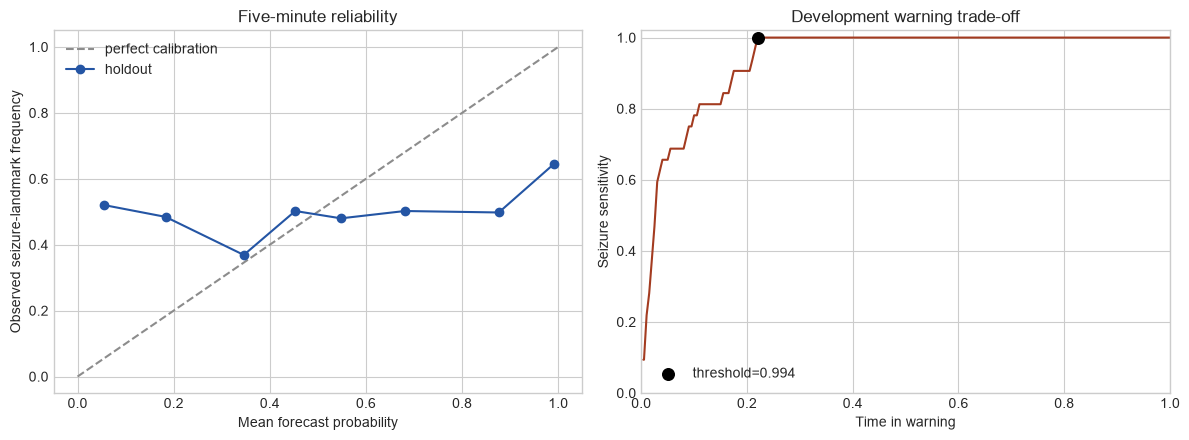

,mean_forecast,observed_frequency,landmarks
0,0.056031,0.520000,225
1,0.183043,0.484444,225
2,0.345834,0.368889,225
3,0.452857,0.502222,225
4,0.547990,0.480000,225
5,0.680845,0.502222,225
6,0.876275,0.497778,225
7,0.990591,0.644444,225


In [6]:
calibration = holdout_predictions[['event_risk_5m', 'has_event_in_5m']].copy()
calibration['risk_group'] = pd.qcut(calibration['event_risk_5m'], q=8, duplicates='drop')
calibration_summary = calibration.groupby('risk_group', observed=True).agg(
    mean_forecast=('event_risk_5m', 'mean'),
    observed_frequency=('has_event_in_5m', 'mean'),
    landmarks=('has_event_in_5m', 'size'),
).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot([0, 1], [0, 1], '--', color='0.55', label='perfect calibration')
axes[0].plot(calibration_summary['mean_forecast'], calibration_summary['observed_frequency'], 'o-', color='#2455A4', label='holdout')
axes[0].set(xlabel='Mean forecast probability', ylabel='Observed seizure-landmark frequency', title='Five-minute reliability')
axes[0].legend()

curve = threshold_curve.sort_values('time_in_warning')
axes[1].plot(curve['time_in_warning'], curve['sensitivity'], color='#A33B20')
selected = curve.iloc[(curve['threshold'] - warning_threshold).abs().argmin()]
axes[1].scatter([selected['time_in_warning']], [selected['sensitivity']], s=70, color='black', zorder=3, label=f'threshold={warning_threshold:.3f}')
axes[1].set(xlabel='Time in warning', ylabel='Seizure sensitivity', title='Development warning trade-off', xlim=(0, 1), ylim=(0, 1.02))
axes[1].legend()
fig.tight_layout()
figure_path = paths['results'] / 'forecast_evaluation.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
display(calibration_summary)

## 9. Fixed-horizon rolling replay

`RollingForecastEngine` reads an EDF directly and caches its last state. Calling it within the same five-second interval does not recompute. At exactly the next boundary it reads the most recent two minutes, forecasts again, removes the elapsed absolute episode bin, and leaves the original episode end unchanged.

The bar height `onset_probability` is unconditional and sums to the displayed event risk. The column `timing_probability_given_event` sums to one and is the requested timing-only graph. The remaining mass is reported as `no_event_probability_by_fixed_end`.

In [7]:
example_episode = manifest.loc[
    manifest['patient_id'].isin(split['holdout_patients']) & manifest['episode_type'].eq('preictal')
].iloc[0]
engine = rsf.RollingForecastEngine(
    model,
    example_episode['edf_path'],
    example_episode['anchor_seconds'],
    config,
)

state_0 = engine.advance_to(example_episode['anchor_seconds'])
state_4_9 = engine.advance_to(example_episode['anchor_seconds'] + 4.9)
state_5 = engine.advance_to(example_episode['anchor_seconds'] + 5.0)
state_60 = engine.advance_to(example_episode['anchor_seconds'] + 60.0)
state_300 = engine.advance_to(example_episode['anchor_seconds'] + 300.0)

boundary_checks = pd.DataFrame([
    {'call': 'anchor + 0.0 s', 'step': state_0['episode_step'], 'recomputed': state_0['recomputed'], 'model_calls': state_0['recomputation_count'], 'first_visible_bin': int(state_0['probability_table']['absolute_episode_bin'].iloc[0])},
    {'call': 'anchor + 4.9 s', 'step': state_4_9['episode_step'], 'recomputed': state_4_9['recomputed'], 'model_calls': state_4_9['recomputation_count'], 'first_visible_bin': int(state_4_9['probability_table']['absolute_episode_bin'].iloc[0])},
    {'call': 'anchor + 5.0 s', 'step': state_5['episode_step'], 'recomputed': state_5['recomputed'], 'model_calls': state_5['recomputation_count'], 'first_visible_bin': int(state_5['probability_table']['absolute_episode_bin'].iloc[0])},
    {'call': 'anchor + 60 s', 'step': state_60['episode_step'], 'recomputed': state_60['recomputed'], 'model_calls': state_60['recomputation_count'], 'first_visible_bin': int(state_60['probability_table']['absolute_episode_bin'].iloc[0])},
    {'call': 'anchor + 300 s', 'step': state_300['episode_step'], 'recomputed': state_300['recomputed'], 'model_calls': state_300['recomputation_count'], 'first_visible_bin': np.nan},
])
assert state_4_9['recomputed'] is False
assert state_0['remaining_bins'] == 60 and state_5['remaining_bins'] == 59
assert state_0['probability_table']['absolute_episode_bin'].iloc[0] == 1
assert state_5['probability_table']['absolute_episode_bin'].iloc[0] == 2
assert state_60['fixed_end_seconds'] == state_0['fixed_end_seconds']
assert state_300['episode_complete'] is True and state_300['remaining_bins'] == 0
assert state_300['probability_table'].empty and state_300['recomputation_count'] == state_60['recomputation_count']
display(boundary_checks)
print(f"Example: {example_episode['episode_id']} from {example_episode['recording']}")

,call,step,recomputed,model_calls,first_visible_bin
0,anchor + 0.0 s,0,True,1,1.0
1,anchor + 4.9 s,0,False,1,1.0
2,anchor + 5.0 s,1,True,2,2.0
3,anchor + 60 s,12,True,3,13.0
4,anchor + 300 s,60,False,3,NaN


Example: PN00_S01_preictal from PN00-1.edf


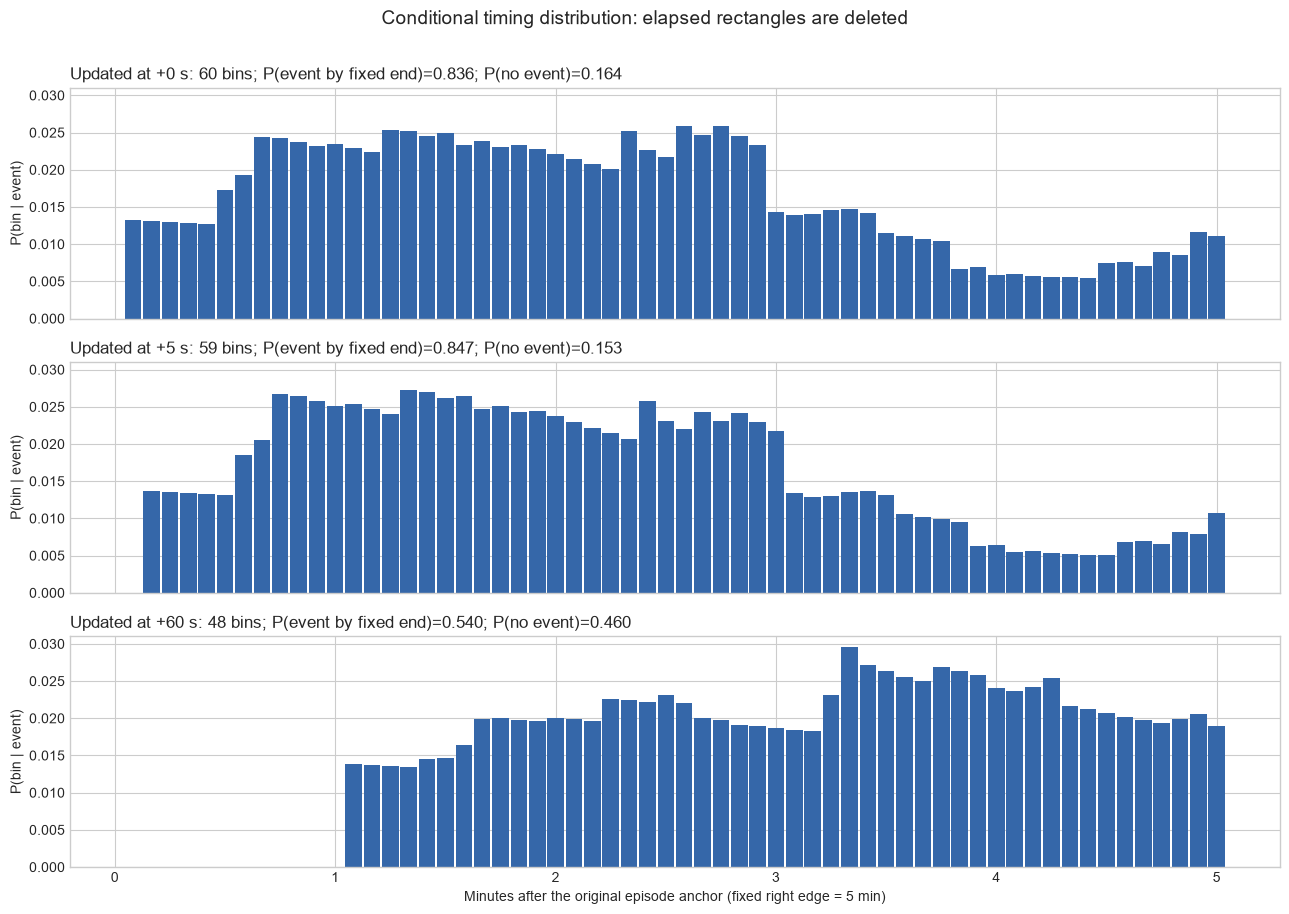

,absolute_episode_bin,interval_start_seconds,interval_end_seconds,seconds_ahead_start,seconds_ahead_end,onset_probability,timing_probability_given_event,cumulative_onset_probability,survival_probability
0,2,5,10,0,5,0.011622,0.0137,0.0116,0.9884
1,3,10,15,5,10,0.011487,0.0136,0.0231,0.9769
2,4,15,20,10,15,0.011353,0.0134,0.0345,0.9655
3,5,20,25,15,20,0.011221,0.0133,0.0457,0.9543
4,6,25,30,20,25,0.011091,0.0131,0.0568,0.9432
5,7,30,35,25,30,0.015675,0.0185,0.0724,0.9276
6,8,35,40,30,35,0.017376,0.0205,0.0898,0.9102
7,9,40,45,35,40,0.022577,0.0267,0.1124,0.8876
8,10,45,50,40,45,0.022418,0.0265,0.1348,0.8652
9,11,50,55,45,50,0.021852,0.0258,0.1567,0.8433


At +5 s, visible onset mass = 0.846861
At +5 s, no-event-by-fixed-end mass = 0.153139
Total = 1.000000000000


In [8]:
states = [('0 s', state_0), ('5 s', state_5), ('60 s', state_60)]
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, sharey=True)
rolling_rows = []
for axis, (label, state) in zip(axes, states, strict=True):
    table = state['probability_table'].copy()
    table['state_elapsed_seconds'] = state['episode_step'] * config.bin_seconds
    rolling_rows.append(table)
    axis.bar(
        table['interval_end_seconds'] / 60,
        table['timing_probability_given_event'],
        width=config.bin_seconds / 60 * 0.9,
        color='#3567A9',
    )
    axis.set_ylabel('P(bin | event)')
    axis.set_title(
        f'Updated at +{label}: {state["remaining_bins"]} bins; '
        f'P(event by fixed end)={state["event_risk_by_fixed_end"]:.3f}; '
        f'P(no event)={state["no_event_probability_by_fixed_end"]:.3f}',
        loc='left',
    )
axes[-1].set_xlabel('Minutes after the original episode anchor (fixed right edge = 5 min)')
fig.suptitle('Conditional timing distribution: elapsed rectangles are deleted', y=1.01, fontsize=14)
fig.tight_layout()
rolling_figure_path = paths['results'] / 'fixed_horizon_rolling_example.png'
fig.savefig(rolling_figure_path, dpi=160, bbox_inches='tight')
plt.show()

rolling_output = pd.concat(rolling_rows, ignore_index=True)
rolling_output.to_csv(paths['results'] / 'fixed_horizon_rolling_example.csv', index=False)
display(state_5['probability_table'].head(12).style.format({
    'onset_probability': '{:.6f}',
    'timing_probability_given_event': '{:.4f}',
    'cumulative_onset_probability': '{:.4f}',
    'survival_probability': '{:.4f}',
}))
print(f"At +5 s, visible onset mass = {state_5['event_risk_by_fixed_end']:.6f}")
print(f"At +5 s, no-event-by-fixed-end mass = {state_5['no_event_probability_by_fixed_end']:.6f}")
print(f"Total = {state_5['event_risk_by_fixed_end'] + state_5['no_event_probability_by_fixed_end']:.12f}")

## 10. Weaknesses and inconsistencies

1. **Absolute probability is not identified by this sample.** The recordings were selected around seizures and the notebook deliberately matches one interictal episode per seizure. The resulting prevalence is artificial; probability calibration does not transfer to daily life.
2. **Only 47 seizures from 14 patients are available.** Sixty overlapping landmarks per event do not create 2,820 independent seizures. All splitting and interpretation must remain patient-grouped.
3. **False alarms/hour is unstable.** The selected interictal replay is short. A clinically useful estimate needs long, continuous, representative recordings including days without seizures.
4. **The fixed five-minute endpoint is an evaluation convention.** In deployment there is no known natural episode start. Repeated episodes need a prespecified schedule and rules for overlap, reset, warning persistence, postictal exclusion, and refractory periods.
5. **Five-second bins imply interval censoring.** Onset labels and annotation repairs are not exact enough to justify interpreting differences smaller than a bin. Soft labels across neighboring bins would better reflect uncertainty.
6. **Two minutes is context, not online learning.** This stateless model does not “start understanding” during those minutes; it deterministically summarizes them using parameters learned from other recordings.
7. **Scalp EEG is artifact-prone and heterogeneous.** Low gamma is truncated to 30–45 Hz to avoid 60 Hz line noise and resampling limits. Sleep, medication, electrode montage, and hospital routine can confound apparent preictal changes.
8. **The current feature model is deliberately small.** It ignores electrode geometry and detailed phase/connectivity structure. A large neural network would overfit this dataset even more severely.
9. **Fresh forecasts need not be temporally coherent.** Re-estimation from new EEG can make adjacent probability curves jump. Temporal-consistency regularization can reduce this, but should not hide genuine signal changes.
10. **Conditional timing bars can look confident when event risk is tiny.** Always display the no-event probability and absolute event risk next to the timing-only graph.

## 11. Improvements within this framework

- Acquire long continuous scalp/subscalp EEG with complete seizure diaries, and preserve real censoring instead of constructing balanced controls.
- Use nested leave-one-patient-out or chronological validation. Select thresholds and calibrators only inside the development split; report patient bootstrap intervals and seizure-time surrogate tests.
- Calibrate the 61-outcome distribution on representative prevalence (temperature scaling, isotonic calibration, or Bayesian prior correction), then verify reliability separately by horizon and patient.
- Replace handcrafted summaries with a causal multichannel encoder only after substantially more independent patients and seizures are available. Keep the same hazard head and no-event mass.
- Add time-of-day, sleep stage, medication, and patient baseline as explicit covariates rather than allowing them to leak through uncontrolled recording context.
- Use soft onset targets across adjacent five-second bins and sensitivity analyses with 10-, 15-, or 30-second bins. Sixty output intervals may be too granular for 47 events.
- Add a temporal-consistency penalty between adjacent landmark survival curves, while allowing data-driven changes after new EEG is observed.
- Define operational rules before testing: warning duration, lockout, postictal exclusion, episode reset, and what counts as one false alarm.
- Compare against transparent baselines: constant patient seizure rate, time-of-day/cycle model, and a model using no EEG. Report Brier skill and improvement over seizure-time surrogates.
- Treat recurrent seizures with a recurrent-event/point-process extension when long recordings become available.

In [9]:
artifact_rows = []
for artifact in sorted(paths['results'].iterdir()):
    if artifact.is_file():
        artifact_rows.append({
            'file': artifact.name,
            'size_kb': round(artifact.stat().st_size / 1024, 1),
            'purpose': {
                'study_summary.csv': 'Readable study/data inventory',
                'episode_manifest.csv': 'Exact EDF episodes and anchors used',
                'holdout_metrics.csv': 'Overall holdout scores',
                'holdout_patient_metrics.csv': 'Per-patient holdout scores',
                'development_warning_curve.csv': 'Sensitivity/TiW threshold trade-off',
                'holdout_landmark_probabilities.csv': 'Every holdout landmark and all 60 bin probabilities',
                'rolling_discrete_hazard_model.joblib': 'Fitted model bundle and configuration',
                'forecast_evaluation.png': 'Calibration and warning trade-off plot',
                'fixed_horizon_rolling_example.png': 'Three boundary-triggered probability graphs',
                'fixed_horizon_rolling_example.csv': 'Readable probability tables behind the rolling plot',
            }.get(artifact.name, 'Generated notebook artifact'),
        })
artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(paths['results'] / 'ARTIFACT_INVENTORY.csv', index=False)
display(artifact_inventory)

display(Markdown(
    '### Completion check\n\n'
    f'- Read **{len(edf_files)} EDF files in the study inventory** and extracted features from **{len(manifest)} selected episodes**.\n'
    f'- Trained on **{len(split["development_patients"])} development patients** and evaluated on **{len(split["holdout_patients"])} unseen patients**.\n'
    f'- Verified nonnegative probabilities, monotone survival, and total mass of one.\n'
    f'- Saved the working model and readable CSV/PNG outputs to `{paths["results"]}`.\n\n'
    '**Conclusion:** the corrected discrete-hazard formulation is mathematically consistent. The implementation works as an offline research prototype, but this dataset cannot support calibrated clinical seizure warnings.'
))

,file,size_kb,purpose
0,ARTIFACT_INVENTORY.csv,0.7,Generated notebook artifact
1,development_warning_curve.csv,12.2,Sensitivity/TiW threshold trade-off
2,episode_manifest.csv,16.1,Exact EDF episodes and anchors used
3,fixed_horizon_rolling_example.csv,16.7,Readable probability tables behind the rolling...
4,fixed_horizon_rolling_example.png,94.6,Three boundary-triggered probability graphs
5,forecast_evaluation.png,87.6,Calibration and warning trade-off plot
6,holdout_landmark_probabilities.csv,2612.8,Every holdout landmark and all 60 bin probabil...
7,holdout_metrics.csv,1.2,Overall holdout scores
8,holdout_patient_metrics.csv,0.4,Per-patient holdout scores
9,rolling_discrete_hazard_model.joblib,333.9,Fitted model bundle and configuration


### Completion check

- Read **41 EDF files in the study inventory** and extracted features from **94 selected episodes**.
- Trained on **10 development patients** and evaluated on **4 unseen patients**.
- Verified nonnegative probabilities, monotone survival, and total mass of one.
- Saved the working model and readable CSV/PNG outputs to `C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\results\rolling_forecast`.

**Conclusion:** the corrected discrete-hazard formulation is mathematically consistent. The implementation works as an offline research prototype, but this dataset cannot support calibrated clinical seizure warnings.

## 12. Reuse on another EDF landmark

After running the notebook, reload the saved bundle and instantiate the boundary-triggered engine. `episode_anchor_seconds` must be at least 120 seconds into the EDF. The original end is always anchor + 300 seconds.

```python
bundle = joblib.load(paths['results'] / 'rolling_discrete_hazard_model.joblib')
engine = rsf.RollingForecastEngine(
    bundle['model'],
    edf_path='path/to/recording.edf',
    episode_anchor_seconds=600,
    config=bundle['config'],
)
forecast = engine.advance_to(600)     # computes
same = engine.advance_to(604.9)       # cached; no update
updated = engine.advance_to(605.0)    # computes; absolute bin 1 is gone
display(updated['probability_table'])
```

Do not interpret the returned numbers as clinical probabilities without representative long-term data and external prospective validation.